In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.options.display.max_rows = 1000

In [2]:
df = pd.read_csv('../data/processed/accepted_features.csv', low_memory=False)

print(df.shape)
print(df.columns.tolist())

(113244, 111)
['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', '

In [8]:
seg_cols = ["grade","purpose","home_ownership","is_default","vintage", "loan_amnt", "int_rate", "dti"]


print(df[seg_cols].dtypes)
print()
print(df[seg_cols].isnull().sum())
print()

for col in ['grade', 'purpose', 'home_ownership']:
    print(f"{col}: {sorted(df[col].dropna().unique().tolist())}")
    print()

grade                 str
purpose               str
home_ownership        str
is_default          int64
vintage               str
loan_amnt         float64
int_rate          float64
dti               float64
dtype: object

grade             0
purpose           0
home_ownership    0
is_default        0
vintage           0
loan_amnt         0
int_rate          0
dti               0
dtype: int64

grade: ['A', 'B', 'C', 'D', 'E', 'F', 'G']

purpose: ['car', 'credit_card', 'debt_consolidation', 'educational', 'home_improvement', 'house', 'major_purchase', 'medical', 'moving', 'other', 'renewable_energy', 'small_business', 'vacation', 'wedding']

home_ownership: ['ANY', 'MORTGAGE', 'NONE', 'OTHER', 'OWN', 'RENT']



In [9]:
df['home_ownership_clean'] = df['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'
})

print(df['home_ownership_clean'].value_counts())
print()



home_ownership_clean
MORTGAGE    55592
RENT        44846
OWN         12752
OTHER          54
Name: count, dtype: int64



In [10]:
top_purposes = df['purpose'].value_counts().nlargest(6).index.tolist()
print("Top 6 purposes:", top_purposes)

df['purpose_clean'] = df['purpose'].apply(
    lambda x: x if x in top_purposes else 'other'
)

print()
print(df['purpose_clean'].value_counts())

Top 6 purposes: ['debt_consolidation', 'credit_card', 'home_improvement', 'other', 'major_purchase', 'medical']

purpose_clean
debt_consolidation    63976
credit_card           25892
other                 11997
home_improvement       7440
major_purchase         2605
medical                1334
Name: count, dtype: int64


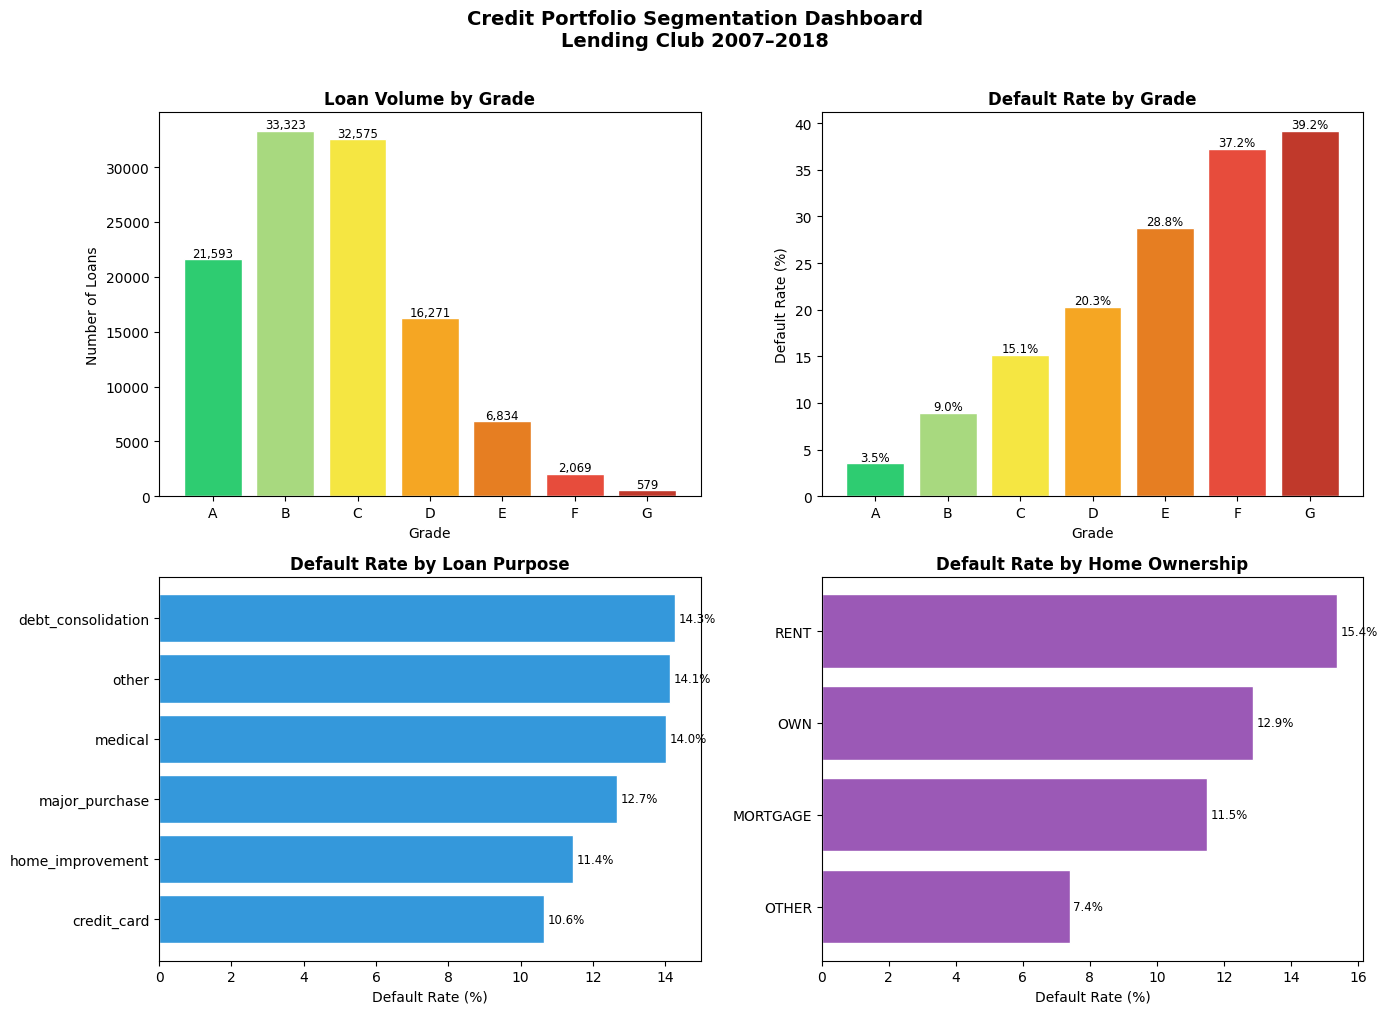

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Portfolio Segmentation Dashboard\nLending Club 2007–2018', 
             fontsize=14, fontweight='bold', y=1.01)

# Top-Left
ax1 = axes[0, 0]
grade_counts = df['grade'].value_counts().reindex(['A','B','C','D','E','F','G'])
bar_colors = ['#2ecc71','#a8d97f','#f5e642','#f5a623','#e67e22','#e74c3c','#c0392b']
ax1.bar(grade_counts.index, grade_counts.values, color=bar_colors, edgecolor='white')
ax1.set_title('Loan Volume by Grade', fontsize=12, fontweight='bold')
ax1.set_xlabel('Grade')
ax1.set_ylabel('Number of Loans')

for i, (idx, val) in enumerate(grade_counts.items()):
    ax1.text(i, val + 200, f'{val:,}', ha='center', fontsize=8.5)

# Top-Right
ax2 = axes[0, 1]
grade_default = df.groupby('grade')['is_default'].mean().reindex(['A','B','C','D','E','F','G']) * 100
ax2.bar(grade_default.index, grade_default.values, color=bar_colors, edgecolor='white')
ax2.set_title('Default Rate by Grade', fontsize=12, fontweight='bold')
ax2.set_xlabel('Grade')
ax2.set_ylabel('Default Rate (%)')
for i, (idx, val) in enumerate(grade_default.items()):
    ax2.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=8.5)

# Bottom Left
ax3 = axes[1, 0]

purpose_default = (df.groupby('purpose_clean')['is_default']
                   .mean()
                   .sort_values(ascending=True) * 100)
ax3.barh(purpose_default.index, purpose_default.values, color='#3498db', edgecolor='white')
ax3.set_title('Default Rate by Loan Purpose', fontsize=12, fontweight='bold')
ax3.set_xlabel('Default Rate (%)')

for i, val in enumerate(purpose_default.values):
    ax3.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8.5)

# Bottom-Left
ax4 = axes[1, 1]
home_default = (df.groupby('home_ownership_clean')['is_default']
                .mean()
                .sort_values(ascending=True) * 100)

ax4.barh(home_default.index, home_default.values, color='#9b59b6', edgecolor='white')
ax4.set_title('Default Rate by Home Ownership', fontsize=12, fontweight='bold')
ax4.set_xlabel('Default Rate (%)')

for i, val in enumerate(home_default.values):
    ax4.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('../outputs/05_portfolio_segmentation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()



## Interpretation: Portfolio Segmentation Dashboard

### Loan Volume by Grade
- Portfolio is concentrated in Grade B and C (33k and 32k loans respectively)
- Grade G has only 579 loans — very thin high-risk segment
- This is typical: most lenders cap exposure to the riskiest borrowers

### Default Rate by Grade
- Clean monotonic increase from A (3.5%) to G (39.2%)
- Grade D onwards crosses the 20% threshold — significant credit risk
- Grade F and G combined represent a charge-off rate above 37%
- Consistent with the roll rate matrix findings in notebook 04

### Default Rate by Loan Purpose
- Spread is relatively narrow — 10.6% to 14.3%
- Credit card payoff loans have the lowest default rate (10.6%)
  — borrowers refinancing credit card debt tend to be more financially disciplined
- Debt consolidation has the highest at 14.3% despite being the most common purpose
- Purpose alone is a weak standalone predictor compared to grade

### Default Rate by Home Ownership
- Renters default at the highest rate (15.4%) vs mortgage holders (11.5%)
- Mortgage holders have demonstrated ability to service long-term debt
- OTHER category is too small (54 loans) to draw conclusions from

### Key takeaway
Grade is by far the strongest single segmentation variable.
Purpose and home ownership add marginal signal but should be 
used in combination with grade for portfolio policy decisions.